# ArcFace — Inferencja wytrenowanego modelu

Notebook demonstruje użycie wytrenowanego modelu ArcFace (IResNet50) do:
- ekstrakcji embeddingów twarzy (512-dim),
- weryfikacji 1:1 (porównanie pary zdjęć),
- identyfikacji 1:N (wyszukanie najbardziej podobnej twarzy w galerii).

## Importy

In [1]:
import math
from pathlib import Path
from collections import defaultdict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

## Konfiguracja

In [2]:
# Ścieżki
BASE_DIR = Path(".")
MODEL_WEIGHTS = BASE_DIR / "results" / "arcface_celeba_best.pth"
IMG_DIR = BASE_DIR / "data" / "processed" / "cropped"
IDENTITY_FILE = BASE_DIR / "data" / "identity_CelebA.txt"
TEST_SPLIT_FILE = BASE_DIR / "data" / "split" / "test_split.txt"

# Parametry modelu
EMBEDDING_SIZE = 512

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


## Definicja architektury — IBasicBlock

In [3]:
class IBasicBlock(nn.Module):
    """Blok residualny IResNet (BN-Conv-BN-PReLU-Conv-BN)."""
    expansion = 1

    def __init__(self, inplanes, planes, stride=1, downsample=None):
        super().__init__()
        self.bn1 = nn.BatchNorm2d(inplanes, eps=1e-05)
        self.conv1 = nn.Conv2d(inplanes, planes, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes, eps=1e-05)
        self.prelu = nn.PReLU(planes)
        self.conv2 = nn.Conv2d(planes, planes, 3, stride, 1, bias=False)
        self.bn3 = nn.BatchNorm2d(planes, eps=1e-05)
        self.downsample = downsample

    def forward(self, x):
        identity = x
        out = self.bn1(x)
        out = self.conv1(out)
        out = self.bn2(out)
        out = self.prelu(out)
        out = self.conv2(out)
        out = self.bn3(out)
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        return out

## Definicja architektury — IResNet

In [4]:
class IResNet(nn.Module):
    """Improved ResNet for face recognition (insightface architecture).

    Input:  (B, 3, 112, 112)
    Output: (B, embedding_size)  — domyślnie 512
    """
    fc_scale = 7 * 7

    def __init__(self, block, layers, embedding_size=512, dropout=0.0):
        super().__init__()
        self.inplanes = 64
        self.conv1 = nn.Conv2d(3, 64, 3, 1, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(64, eps=1e-05)
        self.prelu = nn.PReLU(64)
        self.layer1 = self._make_layer(block, 64, layers[0], stride=2)
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)
        self.bn2 = nn.BatchNorm2d(512 * block.expansion, eps=1e-05)
        self.dropout = nn.Dropout(p=dropout, inplace=True)
        self.fc = nn.Linear(512 * block.expansion * self.fc_scale, embedding_size)
        self.features = nn.BatchNorm1d(embedding_size, eps=1e-05)
        nn.init.constant_(self.features.weight, 1.0)
        self.features.weight.requires_grad = False

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.normal_(m.weight, 0, 0.1)
            elif isinstance(m, (nn.BatchNorm2d, nn.GroupNorm)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def _make_layer(self, block, planes, blocks, stride=1):
        downsample = None
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.inplanes, planes * block.expansion, 1, stride, bias=False),
                nn.BatchNorm2d(planes * block.expansion, eps=1e-05),
            )
        layers = [block(self.inplanes, planes, stride, downsample)]
        self.inplanes = planes * block.expansion
        for _ in range(1, blocks):
            layers.append(block(self.inplanes, planes))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.prelu(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.bn2(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)
        x = self.features(x)
        return x

## Funkcja fabryczna `iresnet50`

In [5]:
def iresnet50(**kwargs):
    return IResNet(IBasicBlock, [3, 4, 14, 3], **kwargs)

## Ładowanie wytrenowanego modelu

In [6]:
model = iresnet50(embedding_size=EMBEDDING_SIZE)

state_dict = torch.load(MODEL_WEIGHTS, map_location="cpu", weights_only=True)
state_dict = {k: v.float() if v.dtype == torch.float16 else v for k, v in state_dict.items()}
model.load_state_dict(state_dict)

model = model.to(device)
model.eval()

print(f"Model załadowany z: {MODEL_WEIGHTS}")
print(f"Parametry: {sum(p.numel() for p in model.parameters()):,}")

Model załadowany z: results\arcface_celeba_best.pth
Parametry: 43,590,848


## Transformacja obrazów (preprocessing)

In [7]:
preprocess = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

## Funkcja ekstrakcji embeddingu

In [8]:
@torch.no_grad()
def get_embedding(model, image_path, transform=preprocess):
    """Zwraca znormalizowany embedding (512-dim) dla pojedynczego obrazu."""
    img = Image.open(image_path).convert("RGB")
    tensor = transform(img).unsqueeze(0).to(device)
    emb = model(tensor)
    emb = F.normalize(emb, p=2, dim=1)
    return emb.cpu().squeeze(0)


@torch.no_grad()
def get_embeddings_batch(model, image_paths, transform=preprocess, batch_size=64):
    """Zwraca znormalizowane embeddingi dla listy obrazów."""
    all_emb = []
    for i in range(0, len(image_paths), batch_size):
        batch_paths = image_paths[i : i + batch_size]
        images = torch.stack([
            transform(Image.open(p).convert("RGB")) for p in batch_paths
        ]).to(device)
        emb = model(images)
        emb = F.normalize(emb, p=2, dim=1)
        all_emb.append(emb.cpu())
    return torch.cat(all_emb, dim=0)

## Weryfikacja 1:1 — porównanie dwóch twarzy

In [9]:
def verify(model, img_path1, img_path2, threshold=0.5):
    """Weryfikacja 1:1 — czy dwa zdjęcia przedstawiają tę samą osobę.

    Args:
        model: wytrenowany backbone IResNet50
        img_path1, img_path2: ścieżki do cropowanych zdjęć (112x112)
        threshold: próg cosine similarity (domyślnie 0.5)

    Returns:
        (is_same: bool, similarity: float)
    """
    emb1 = get_embedding(model, img_path1)
    emb2 = get_embedding(model, img_path2)
    similarity = F.cosine_similarity(emb1.unsqueeze(0), emb2.unsqueeze(0)).item()
    return similarity >= threshold, similarity

## Identyfikacja 1:N — wyszukanie w galerii

In [10]:
def identify(model, query_path, gallery_paths, gallery_labels, top_k=5):
    """Identyfikacja 1:N — wyszukanie najbardziej podobnych twarzy w galerii.

    Args:
        model: wytrenowany backbone IResNet50
        query_path: ścieżka do zdjęcia zapytania
        gallery_paths: lista ścieżek do zdjęć galerii
        gallery_labels: lista etykiet (identity) odpowiadających gallery_paths
        top_k: ile najlepszych wyników zwrócić

    Returns:
        lista krotek (label, similarity, path) posortowana malejąco po similarity
    """
    query_emb = get_embedding(model, query_path).unsqueeze(0)
    gallery_emb = get_embeddings_batch(model, gallery_paths)
    similarities = F.cosine_similarity(query_emb, gallery_emb, dim=1)

    top_indices = similarities.argsort(descending=True)[:top_k]
    results = []
    for idx in top_indices:
        results.append((
            gallery_labels[idx],
            similarities[idx].item(),
            gallery_paths[idx],
        ))
    return results

## Przygotowanie danych testowych

In [11]:
# Wczytanie mapowania: filename -> identity_id
file_to_identity = {}
with open(IDENTITY_FILE, "r") as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) != 2:
            continue
        orig_filename, identity_id = parts[0], int(parts[1])
        cropped_name = Path(orig_filename).stem + "_cropped.jpg"
        if (IMG_DIR / cropped_name).exists():
            file_to_identity[cropped_name] = identity_id

# Wczytanie tożsamości ze zbioru testowego
test_ids = set()
with open(TEST_SPLIT_FILE, "r") as f:
    for line in f:
        test_ids.add(int(line.strip()))

# Zbudowanie mapowania identity -> lista plików (tylko test)
identity_to_files = defaultdict(list)
for fname, identity in file_to_identity.items():
    if identity in test_ids:
        identity_to_files[identity].append(fname)

print(f"Tożsamości testowe: {len(identity_to_files)}")
print(f"Obrazów testowych: {sum(len(v) for v in identity_to_files.values())}")

Tożsamości testowe: 1402
Obrazów testowych: 29938


## Demo: Weryfikacja 1:1

Porównanie par zdjęć — positive (ta sama osoba) i negative (różne osoby).

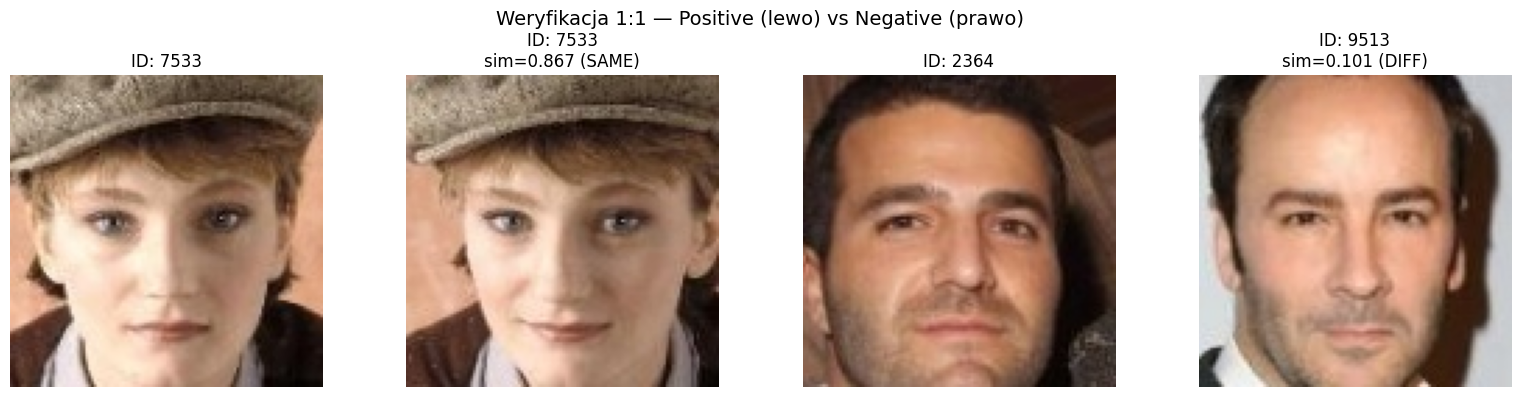

In [12]:
import random
random.seed(42)

# Wybierz tożsamości z >= 2 zdjęciami do pary positive
ids_with_multiple = [id_ for id_, files in identity_to_files.items() if len(files) >= 2]

# Para positive (ta sama osoba)
pos_id = random.choice(ids_with_multiple)
pos_f1, pos_f2 = random.sample(identity_to_files[pos_id], 2)

# Para negative (różne osoby)
neg_id1, neg_id2 = random.sample(list(identity_to_files.keys()), 2)
neg_f1 = random.choice(identity_to_files[neg_id1])
neg_f2 = random.choice(identity_to_files[neg_id2])

# Weryfikacja
pos_same, pos_sim = verify(model, IMG_DIR / pos_f1, IMG_DIR / pos_f2)
neg_same, neg_sim = verify(model, IMG_DIR / neg_f1, IMG_DIR / neg_f2)

# Wizualizacja
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(Image.open(IMG_DIR / pos_f1))
axes[0].set_title(f"ID: {pos_id}")
axes[0].axis("off")

axes[1].imshow(Image.open(IMG_DIR / pos_f2))
axes[1].set_title(f"ID: {pos_id}\nsim={pos_sim:.3f} ({'SAME' if pos_same else 'DIFF'})")
axes[1].axis("off")

axes[2].imshow(Image.open(IMG_DIR / neg_f1))
axes[2].set_title(f"ID: {neg_id1}")
axes[2].axis("off")

axes[3].imshow(Image.open(IMG_DIR / neg_f2))
axes[3].set_title(f"ID: {neg_id2}\nsim={neg_sim:.3f} ({'SAME' if neg_same else 'DIFF'})")
axes[3].axis("off")

fig.suptitle("Weryfikacja 1:1 — Positive (lewo) vs Negative (prawo)", fontsize=14)
plt.tight_layout()
plt.show()

## Demo: Identyfikacja 1:N

Dla wybranego zdjęcia wyszukiwany jest najbardziej podobny obraz w galerii testowej.

Query: 009361_cropped.jpg (tożsamość: 2757)
Galeria: 1402 tożsamości



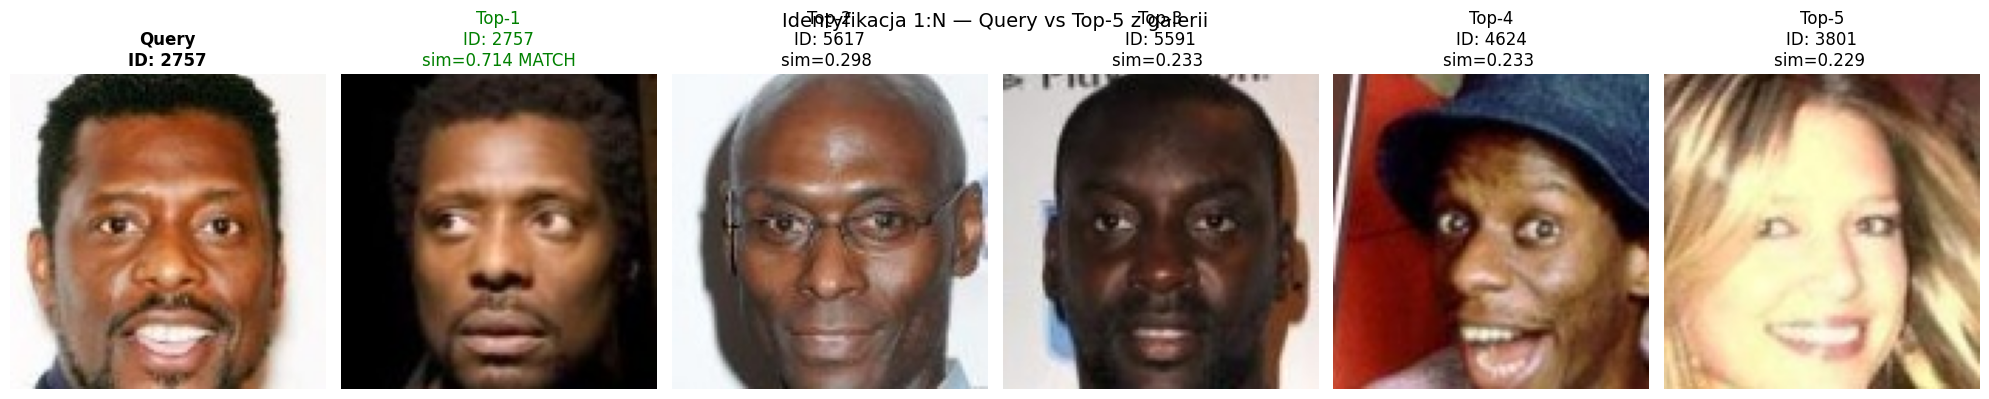


Top-5 wyników:
  1. ID=2757  sim=0.7142  001586_cropped.jpg <-- MATCH
  2. ID=5617  sim=0.2983  005497_cropped.jpg
  3. ID=5591  sim=0.2331  008512_cropped.jpg
  4. ID=4624  sim=0.2330  163462_cropped.jpg
  5. ID=3801  sim=0.2288  008499_cropped.jpg


In [13]:
# Budowanie galerii — jedno zdjęcie na tożsamość
gallery_paths = []
gallery_labels = []
for identity, files in identity_to_files.items():
    gallery_paths.append(IMG_DIR / files[0])
    gallery_labels.append(identity)

# Zdjęcie zapytania — drugie zdjęcie wybranej tożsamości (nie w galerii)
query_id = random.choice(ids_with_multiple)
query_file = identity_to_files[query_id][1]  # inne zdjęcie niż w galerii
query_path = IMG_DIR / query_file

print(f"Query: {query_file} (tożsamość: {query_id})")
print(f"Galeria: {len(gallery_paths)} tożsamości")
print()

# Identyfikacja
results = identify(model, query_path, gallery_paths, gallery_labels, top_k=5)

# Wizualizacja
fig, axes = plt.subplots(1, 6, figsize=(20, 4))

axes[0].imshow(Image.open(query_path))
axes[0].set_title(f"Query\nID: {query_id}", fontweight="bold")
axes[0].axis("off")

for i, (label, sim, path) in enumerate(results):
    match = "MATCH" if label == query_id else ""
    color = "green" if label == query_id else "black"
    axes[i + 1].imshow(Image.open(path))
    axes[i + 1].set_title(f"Top-{i+1}\nID: {label}\nsim={sim:.3f} {match}", color=color)
    axes[i + 1].axis("off")

fig.suptitle("Identyfikacja 1:N — Query vs Top-5 z galerii", fontsize=14)
plt.tight_layout()
plt.show()

print("\nTop-5 wyników:")
for i, (label, sim, path) in enumerate(results):
    match = " <-- MATCH" if label == query_id else ""
    print(f"  {i+1}. ID={label}  sim={sim:.4f}  {Path(path).name}{match}")

## Demo: Ekstrakcja embeddingu dla dowolnego obrazu

In [14]:
# Przykład ekstrakcji surowego embeddingu
sample_file = list(identity_to_files.values())[0][0]
sample_path = IMG_DIR / sample_file

embedding = get_embedding(model, sample_path)

print(f"Obraz: {sample_file}")
print(f"Embedding shape: {embedding.shape}")
print(f"Embedding norm (L2): {embedding.norm().item():.4f}")
print(f"Embedding (pierwsze 10 wartości): {embedding[:10].numpy()}")

Obraz: 000001_cropped.jpg
Embedding shape: torch.Size([512])
Embedding norm (L2): 1.0000
Embedding (pierwsze 10 wartości): [ 0.05484135  0.04211305  0.00011784 -0.06706978  0.02663159 -0.0081676
  0.00882452  0.07394588  0.00343248  0.05731666]


***TESTY***

In [15]:
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import torch
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
import matplotlib.patches as mpatches
import matplotlib.lines as mlines


THRESHOLD = 0.55 

all_identities = list(identity_to_files.keys())
genuine_pairs = []
impostor_pairs_enrolled = []

def get_average_embedding(img_paths, model, get_embedding_fn):
    embeddings = []
    with torch.no_grad():
        for path in img_paths:
            emb = get_embedding_fn(model, path)
            embeddings.append(emb)
    stacked_embeddings = torch.stack(embeddings)
    avg_emb = torch.mean(stacked_embeddings, dim=0)
    avg_emb = F.normalize(avg_emb, p=2, dim=0) 
    return avg_emb

def extract_sim_multi(enrolled_profile_emb, probe_img_path, model, get_embedding_fn):
    with torch.no_grad():
        probe_emb = get_embedding_fn(model, probe_img_path)
        probe_emb = F.normalize(probe_emb, p=2, dim=0)
        sim = F.cosine_similarity(enrolled_profile_emb.unsqueeze(0), probe_emb.unsqueeze(0))
        return (sim.item() + 1.0) / 2.0

def evaluate_and_get_errors(test_cases, threshold=0.45, title="Ewaluacja"):
    y_true, y_scores = [], []
    errors = {'fp': [], 'fn': []}  # fp = FAR (Fałszywa Akceptacja), fn = FRR (Błędne Odrzucenie)
    
    for enroll_paths, profile_emb, probe_path, label in test_cases:
        score = extract_sim_multi(profile_emb, probe_path, model, get_embedding)
        y_true.append(label)
        y_scores.append(score)
        
        if score >= threshold and label == 0:
            errors['fp'].append((enroll_paths, probe_path, score))
        elif score < threshold and label == 1:
            errors['fn'].append((enroll_paths, probe_path, score))
            
    y_pred = [1 if s >= threshold else 0 for s in y_scores]
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    
    acc = accuracy_score(y_true, y_pred)
    far = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    frr = fn / (fn + tp) if (fn + tp) > 0 else 0.0

    print(f"\n{'='*50}")
    print(f"RAPORT: {title}")
    print(f"Ilość prób: {len(test_cases)} (Genuine: {sum(y_true)}, Impostor: {len(y_true)-sum(y_true)})")
    print(f"Próg (Threshold): {threshold}")
    print(f"Accuracy: {acc:.4f}")
    print(f"FAR (Skuteczne podszycia / FP): {far:.4f} ({fp} błędów na {fp+tn} prób oszustwa)")
    print(f"FRR (Błędne odrzucenia / FN):   {frr:.4f} ({fn} błędów na {fn+tp} prawdziwych logowań)")
    print(f"{'='*50}\n")
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=14, y=1.05)
    
    hue_labels = ["Genuine (1)" if y == 1 else "Impostor (0)" for y in y_true]
    sns.histplot(x=y_scores, hue=hue_labels, bins=40, kde=True, 
                 palette={"Genuine (1)": "green", "Impostor (0)": "red"}, legend=False, ax=axes[0])
                 
    axes[0].axvline(threshold, color='black', linestyle='--', linewidth=2)
    axes[0].set_title("Rozkład Podobieństwa")
    axes[0].set_xlabel("Cosine Similarity")
    axes[0].set_ylabel("Liczba wystąpień")
    
    genuine_patch = mpatches.Patch(color='green', label='Genuine (1)')
    impostor_patch = mpatches.Patch(color='red', label='Impostor (0)')
    thresh_line = mlines.Line2D([], [], color='black', linestyle='--', linewidth=2, label=f'Threshold ({threshold})')
    axes[0].legend(handles=[genuine_patch, impostor_patch, thresh_line])
    axes[0].grid(alpha=0.3)
    
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[1],
                xticklabels=["Odrzucenie (0)", "Akceptacja (1)"], 
                yticklabels=["Impostor (0)", "Genuine (1)"],
                annot_kws={"size": 14})
                
    axes[1].set_title("Macierz Pomyłek (Confusion Matrix)")
    axes[1].set_ylabel("Rzeczywista tożsamość")
    axes[1].set_xlabel("Decyzja systemu biometrycznego")

    plt.tight_layout()
    plt.show()
    
    return far, frr, errors

def visualize_error_cases(errors_dict, max_samples=3):
    """
    Wyświetla zdjęcia obrazujące błędy systemu: FAR (Podszycia) i FRR (Odrzucenia).
    """
    has_fp = len(errors_dict['fp']) > 0
    has_fn = len(errors_dict['fn']) > 0
    
    if not has_fp and not has_fn:
        print("Brak błędów do wizualizacji! System zadziałał bezbłędnie dla tego progu.")
        return

    fig, axes = plt.subplots(2, max_samples * 2, figsize=(4 * max_samples, 8))
    fig.suptitle("Wizualizacja Błędów Systemu Biometrycznego", fontsize=16, y=1.02)
    
    for i in range(max_samples):
        ax_base, ax_probe = axes[0, 2*i], axes[0, 2*i+1]
        if i < len(errors_dict['fp']):
            enroll_paths, probe_path, score = errors_dict['fp'][i]
            ax_base.imshow(Image.open(enroll_paths[0]))
            ax_base.set_title("Wzorzec (Z bazy)", color='blue')
            ax_probe.imshow(Image.open(probe_path))
            ax_probe.set_title(f"FAR: Impostor\nScore: {score:.3f}", color='red')
        ax_base.axis('off'); ax_probe.axis('off')

    for i in range(max_samples):
        ax_base, ax_probe = axes[1, 2*i], axes[1, 2*i+1]
        if i < len(errors_dict['fn']):
            enroll_paths, probe_path, score = errors_dict['fn'][i]
            ax_base.imshow(Image.open(enroll_paths[0]))
            ax_base.set_title("Wzorzec (Z bazy)", color='blue')
            ax_probe.imshow(Image.open(probe_path))
            ax_probe.set_title(f"FRR: Genuine (Odrzucono)\nScore: {score:.3f}", color='orange')
        ax_base.axis('off'); ax_probe.axis('off')

    plt.tight_layout()
    plt.show()


valid_identities = [vid for vid in all_identities if len(identity_to_files[vid]) >= 4]  [:500]  # Ograniczamy do 500 osób, jeśli jest więcej


split_idx = int(len(valid_identities) * 0.8)
enrolled_identities = valid_identities[:split_idx]
unenrolled_identities = valid_identities[split_idx:]

enrolled_profiles = {}
print(f"Tworzenie profili (Multi-Enroll) dla {len(enrolled_identities)} użytkowników...")
for vid in enrolled_identities:
    files = identity_to_files[vid]
    enroll_paths = [IMG_DIR / p for p in files[:3]]
    profile_emb = get_average_embedding(enroll_paths, model, get_embedding)
    enrolled_profiles[vid] = (enroll_paths, profile_emb)
print("Profile gotowe!")

Tworzenie profili (Multi-Enroll) dla 400 użytkowników...
Profile gotowe!



RAPORT: EKSPERYMENT: Skuteczność algorytmu
Ilość prób: 1600 (Genuine: 800, Impostor: 800)
Próg (Threshold): 0.55
Accuracy: 0.9494
FAR (Skuteczne podszycia / FP): 0.0912 (73 błędów na 800 prób oszustwa)
FRR (Błędne odrzucenia / FN):   0.0100 (8 błędów na 800 prawdziwych logowań)



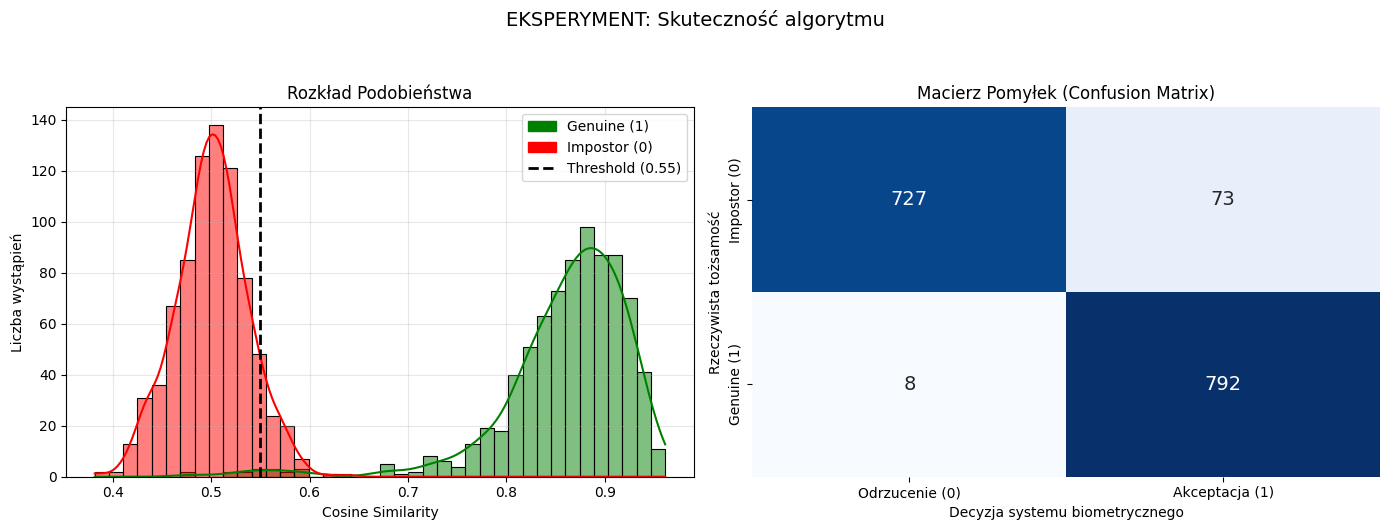

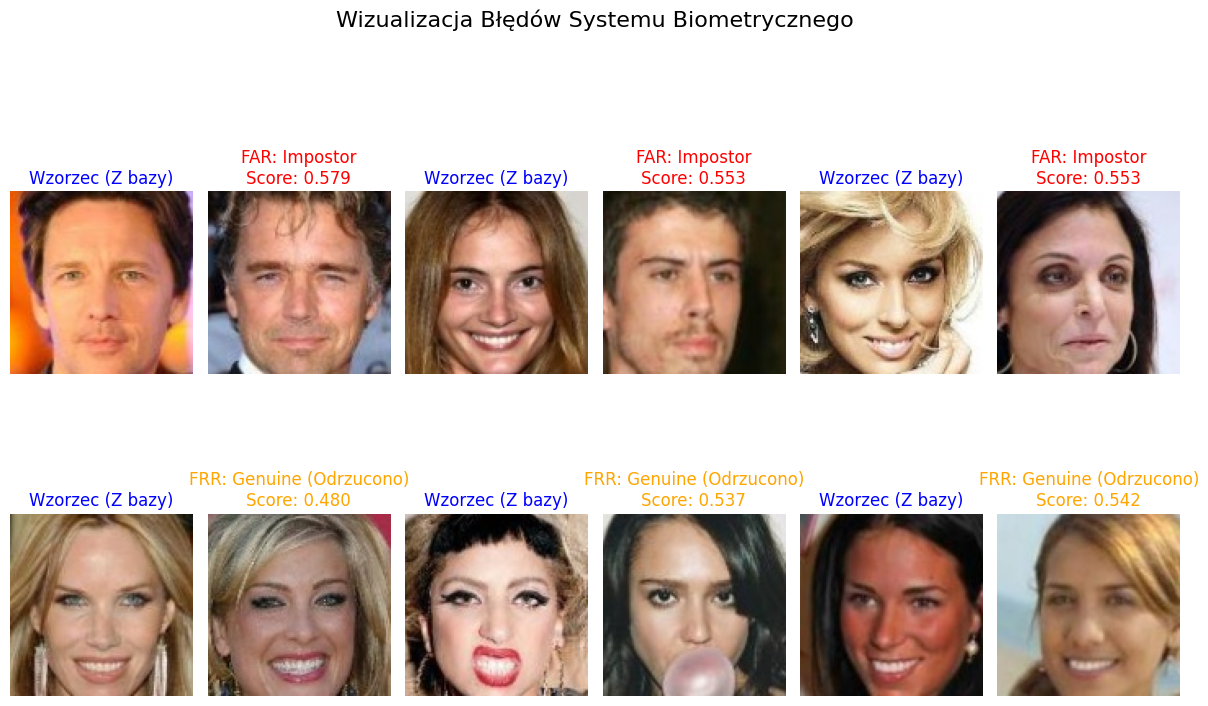

In [16]:
THRESHOLD = 0.55 
genuine_cases = []
impostor_cases_enrolled = []

for vid in enrolled_identities:
    enroll_paths, profile_emb = enrolled_profiles[vid]
    files = identity_to_files[vid]
    
    for probe_img in files[3:]:
        probe_path = IMG_DIR / probe_img
        genuine_cases.append((enroll_paths, profile_emb, probe_path, 1))
        
    for _ in range(2):
        impostor_vid = random.choice([id for id in enrolled_identities if id != vid])
        impostor_img = random.choice(identity_to_files[impostor_vid])
        impostor_path = IMG_DIR / impostor_img
        impostor_cases_enrolled.append((enroll_paths, profile_emb, impostor_path, 0))

min_samples = min(len(genuine_cases), len(impostor_cases_enrolled))
target_half = max(250, min_samples)

random.shuffle(genuine_cases)
random.shuffle(impostor_cases_enrolled)

balanced_genuine = genuine_cases[:target_half]
balanced_impostor_enrolled = impostor_cases_enrolled[:target_half]

experiment_1_cases = balanced_genuine + balanced_impostor_enrolled
random.shuffle(experiment_1_cases)

far_exp1, frr_exp1, test_errors_exp1 = evaluate_and_get_errors(
    experiment_1_cases,
    threshold=THRESHOLD, 
    title="EKSPERYMENT: Skuteczność algorytmu"
)

visualize_error_cases(test_errors_exp1, max_samples=3)


RAPORT: EKSPERYMENT: ataki z wew i zewnątrz (Obcy + Wdrożeni)
Ilość prób: 1700 (Genuine: 800, Impostor: 900)
Próg (Threshold): 0.55
Accuracy: 0.9482
FAR (Skuteczne podszycia / FP): 0.0889 (80 błędów na 900 prób oszustwa)
FRR (Błędne odrzucenia / FN):   0.0100 (8 błędów na 800 prawdziwych logowań)



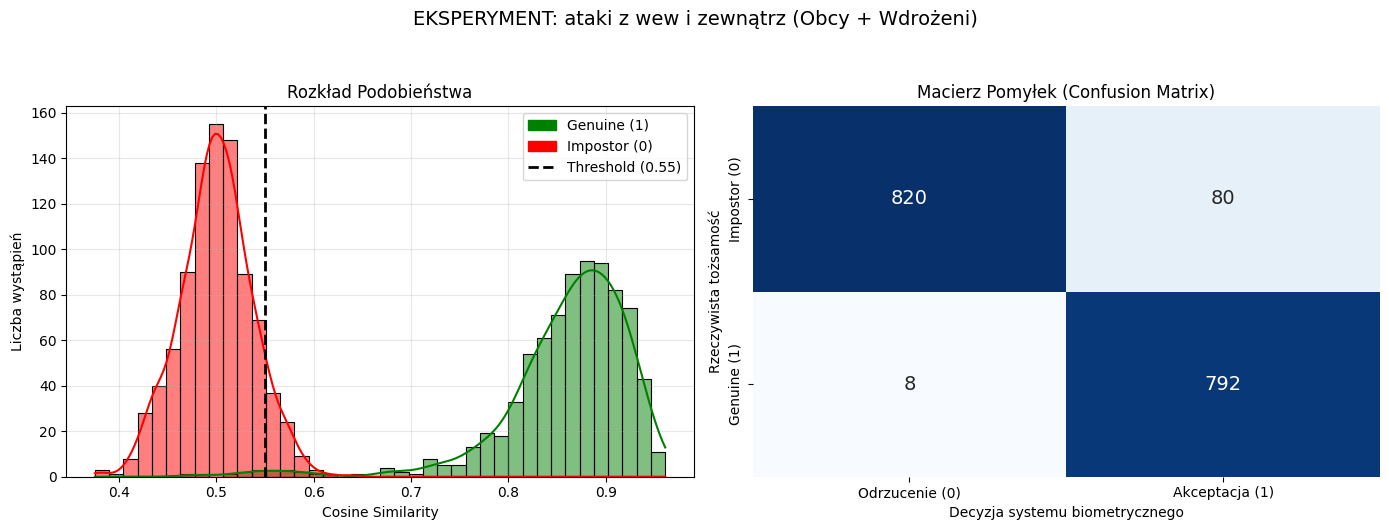


RAPORT: EKSPERYMENT: tylko ataki z zewnątrz
Ilość prób: 100 (Genuine: 0, Impostor: 100)
Próg (Threshold): 0.55
Accuracy: 0.9300
FAR (Skuteczne podszycia / FP): 0.0700 (7 błędów na 100 prób oszustwa)
FRR (Błędne odrzucenia / FN):   0.0000 (0 błędów na 0 prawdziwych logowań)



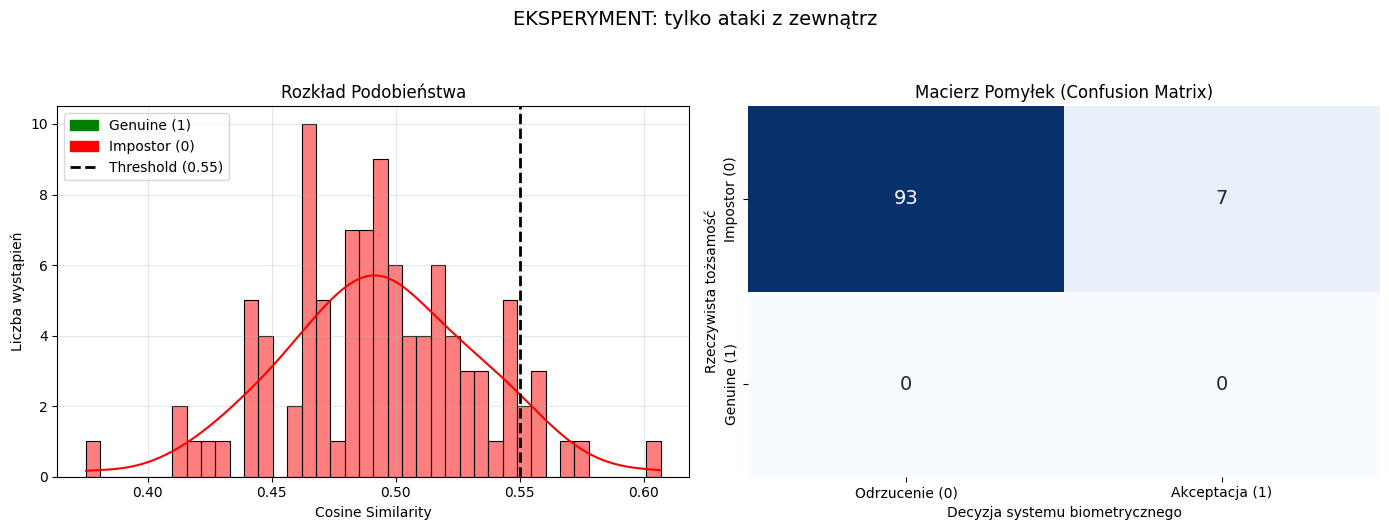

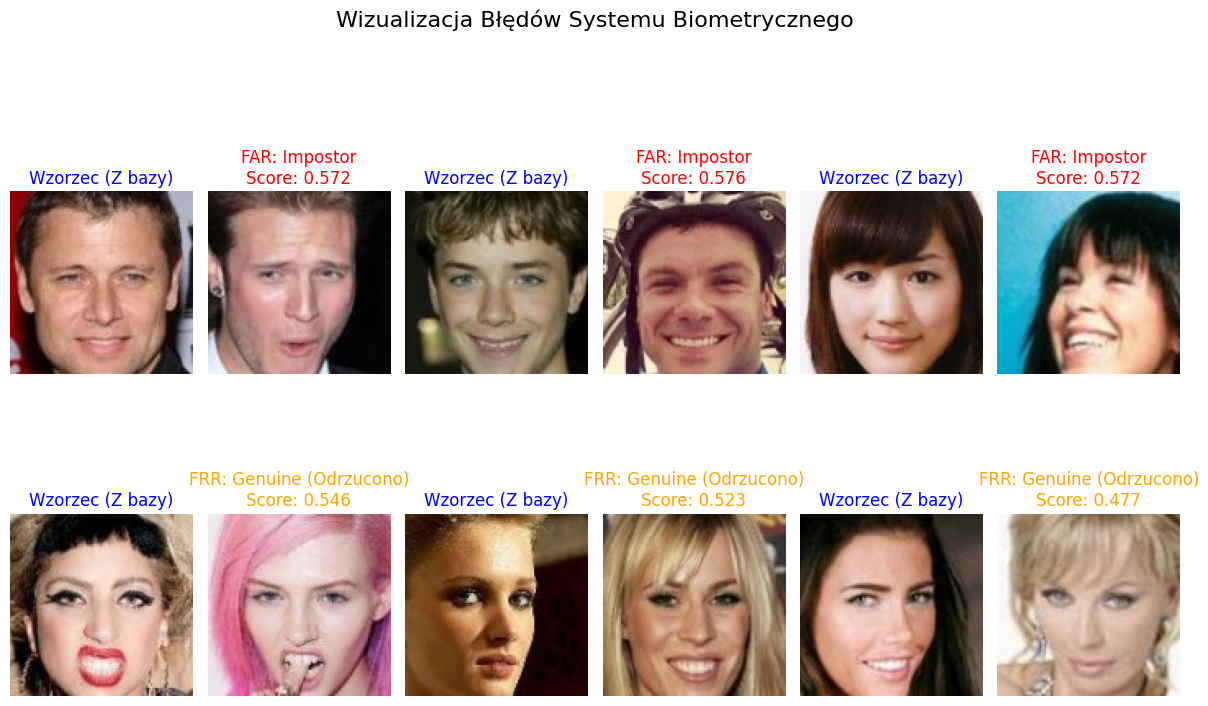


=== PODSUMOWANIE ZMIANY PODATNOŚCI (Wpływ Obcych) ===
FAR (Eksperyment 1 - tylko wew bazy): 0.0912
FAR (Eksperyment 2 - z intruzami z zewnątrz): 0.0889
FAR (Eksperyment 2 - tylko z intruzami z zewnątrz): 0.0700


In [20]:
impostor_cases_unenrolled = []
THRESHOLD = 0.55 
for vid in enrolled_identities:
    enroll_paths, profile_emb = enrolled_profiles[vid]
    
    alien_vid = random.choice(unenrolled_identities)
    alien_img = random.choice(identity_to_files[alien_vid])
    alien_path = IMG_DIR / alien_img
    
    impostor_cases_unenrolled.append((enroll_paths, profile_emb, alien_path, 0))

random.shuffle(impostor_cases_unenrolled)

alien_impostors = impostor_cases_unenrolled[:100]

experiment_2_cases = experiment_1_cases + alien_impostors
random.shuffle(experiment_2_cases)


far_exp2, frr_exp2, test_errors_exp2 = evaluate_and_get_errors(
    experiment_2_cases, 
    threshold=THRESHOLD, 
    title="EKSPERYMENT: ataki z wew i zewnątrz (Obcy + Wdrożeni)"
)

far_exp_alien_only_2, frr_exp_alien_only_2, test_errors_exp_alien_only_2 = evaluate_and_get_errors(
    alien_impostors,  
    threshold=THRESHOLD, 
    title="EKSPERYMENT: tylko ataki z zewnątrz"
)

visualize_error_cases(test_errors_exp2, max_samples=3)


print("\n=== PODSUMOWANIE ZMIANY PODATNOŚCI (Wpływ Obcych) ===")
print(f"FAR (Eksperyment 1 - tylko wew bazy): {far_exp1:.4f}")
print(f"FAR (Eksperyment 2 - z intruzami z zewnątrz): {far_exp2:.4f}")
print(f"FAR (Eksperyment 2 - tylko z intruzami z zewnątrz): {far_exp_alien_only_2:.4f}")


***___________________***

=== EKSPERYMENT 3: Test PSNR na 1600 zdjęciach ===
Obliczanie statystyk dla zdjęć bazowych (Bez szumu)...
Generowanie i testowanie dla przedziału PSNR: (50, 80) dB...
Generowanie i testowanie dla przedziału PSNR: (40, 50) dB...
Generowanie i testowanie dla przedziału PSNR: (30, 40) dB...
Generowanie i testowanie dla przedziału PSNR: (20, 30) dB...
Generowanie i testowanie dla przedziału PSNR: (10, 20) dB...


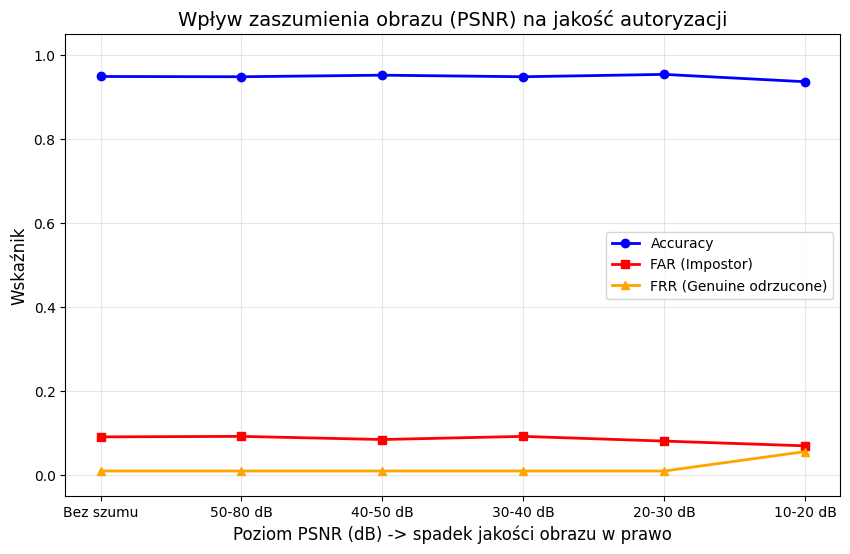


Podsumowanie liczbowe:
PSNR Bez szumu | Accuracy: 0.9494 | FAR: 0.0912 | FRR: 0.0100
PSNR  50-80 dB | Accuracy: 0.9487 | FAR: 0.0925 | FRR: 0.0100
PSNR  40-50 dB | Accuracy: 0.9525 | FAR: 0.0850 | FRR: 0.0100
PSNR  30-40 dB | Accuracy: 0.9487 | FAR: 0.0925 | FRR: 0.0100
PSNR  20-30 dB | Accuracy: 0.9544 | FAR: 0.0813 | FRR: 0.0100
PSNR  10-20 dB | Accuracy: 0.9369 | FAR: 0.0700 | FRR: 0.0563


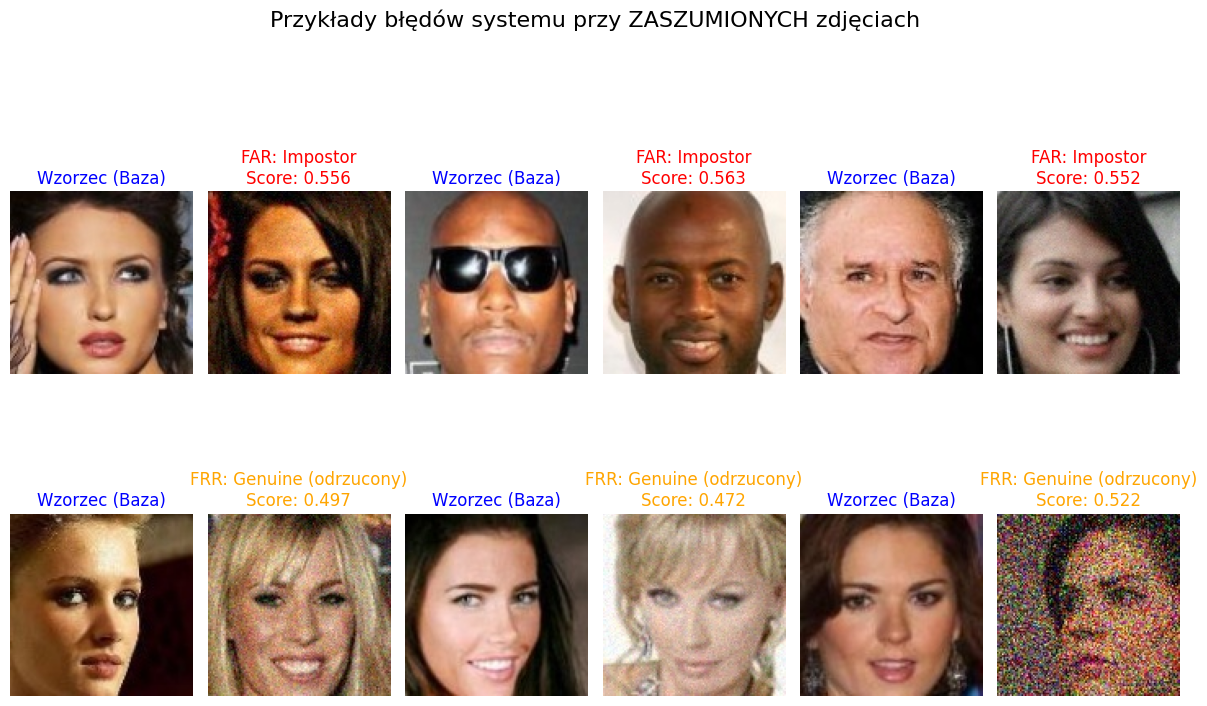

In [18]:
import cv2
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import accuracy_score, confusion_matrix

os.makedirs("temp_noise", exist_ok=True)

# Próg domyślny
THRESHOLD = 0.55

def quick_eval_with_errors(test_cases, threshold=0.45):
    """Oblicza statystyki i zwraca słownik z błędnymi parami zdjęć."""
    y_true, y_scores = [], []
    errors = {'fp': [], 'fn': []}
    
    for enroll_paths, profile_emb, probe_path, label in test_cases:
        score = extract_sim_multi(profile_emb, probe_path, model, get_embedding)
        y_true.append(label)
        y_scores.append(score)
        
        if score >= threshold and label == 0:
            errors['fp'].append((enroll_paths, probe_path, score))
        elif score < threshold and label == 1:
            errors['fn'].append((enroll_paths, probe_path, score))
            
    y_pred = [1 if s >= threshold else 0 for s in y_scores]
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    
    acc = accuracy_score(y_true, y_pred)
    far = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    frr = fn / (fn + tp) if (fn + tp) > 0 else 0.0
    
    return acc, far, frr, errors

def apply_gaussian_noise_psnr(image_path, out_path, psnr_range):
    img = cv2.imread(str(image_path))
    if img is None: return image_path
    
    target_psnr = random.uniform(psnr_range[0], psnr_range[1])
    
    sigma = 255.0 / (10.0 ** (target_psnr / 20.0))
    
    noise = np.random.normal(0, sigma, img.shape)
    noisy_img = np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)
    
    cv2.imwrite(str(out_path), noisy_img)
    return out_path

def visualize_noise_errors(errors_dict, max_samples=3):
    """Wyświetla przykłady FAR i FRR dla zaszumionych zdjęć."""
    has_fp = len(errors_dict['fp']) > 0
    has_fn = len(errors_dict['fn']) > 0
    
    if not has_fp and not has_fn:
        print("Brak pomyłek do wyświetlenia.")
        return

    fig, axes = plt.subplots(2, max_samples * 2, figsize=(4 * max_samples, 8))
    fig.suptitle("Przykłady błędów systemu przy ZASZUMIONYCH zdjęciach", fontsize=16, y=1.02)
    
    for i in range(max_samples):
        ax_base, ax_probe = axes[0, 2*i], axes[0, 2*i+1]
        if i < len(errors_dict['fp']):
            enroll_paths, probe_path, score = errors_dict['fp'][i]
            ax_base.imshow(Image.open(enroll_paths[0]))
            ax_base.set_title("Wzorzec (Baza)", color='blue')
            ax_probe.imshow(Image.open(probe_path))
            ax_probe.set_title(f"FAR: Impostor\nScore: {score:.3f}", color='red')
        ax_base.axis('off'); ax_probe.axis('off')

    for i in range(max_samples):
        ax_base, ax_probe = axes[1, 2*i], axes[1, 2*i+1]
        if i < len(errors_dict['fn']):
            enroll_paths, probe_path, score = errors_dict['fn'][i]
            ax_base.imshow(Image.open(enroll_paths[0]))
            ax_base.set_title("Wzorzec (Baza)", color='blue')
            ax_probe.imshow(Image.open(probe_path))
            ax_probe.set_title(f"FRR: Genuine (odrzucony)\nScore: {score:.3f}", color='orange')
        ax_base.axis('off'); ax_probe.axis('off')

    plt.tight_layout()
    plt.show()

noise_test_cases = experiment_1_cases

psnr_ranges = [(50, 80), (40, 50), (30, 40), (20, 30), (10, 20)]
results_noise = []
all_collected_errors = {'fp': [], 'fn': []}

print(f"=== EKSPERYMENT 3: Test PSNR na {len(noise_test_cases)} zdjęciach ===")

print("Obliczanie statystyk dla zdjęć bazowych (Bez szumu)...")
acc_base, far_base, frr_base, errors_base = quick_eval_with_errors(noise_test_cases, threshold=THRESHOLD)
results_noise.append({'range': "Bez szumu", 'acc': acc_base, 'far': far_base, 'frr': frr_base})
all_collected_errors['fp'].extend(errors_base['fp'])
all_collected_errors['fn'].extend(errors_base['fn'])

for r in psnr_ranges:
    print(f"Generowanie i testowanie dla przedziału PSNR: {r} dB...")
    current_tests = []
    
    for i, (enroll_paths, profile_emb, probe_path, label) in enumerate(noise_test_cases):
        temp_out = f"temp_noise/noise_{r[0]}_{r[1]}_{i}.jpg"
        noisy_probe = apply_gaussian_noise_psnr(probe_path, temp_out, r)
        current_tests.append((enroll_paths, profile_emb, noisy_probe, label))
        
    acc, far, frr, errors = quick_eval_with_errors(current_tests, threshold=THRESHOLD)
    results_noise.append({'range': f"{r[0]}-{r[1]} dB", 'acc': acc, 'far': far, 'frr': frr})
    
    all_collected_errors['fp'].extend(errors['fp'])
    all_collected_errors['fn'].extend(errors['fn'])

labels = [res['range'] for res in results_noise]
acc_vals = [res['acc'] for res in results_noise]
far_vals = [res['far'] for res in results_noise]
frr_vals = [res['frr'] for res in results_noise]

plt.figure(figsize=(10, 6))
plt.plot(labels, acc_vals, marker='o', lw=2, color='blue', label='Accuracy')
plt.plot(labels, far_vals, marker='s', lw=2, color='red', label='FAR (Impostor)')
plt.plot(labels, frr_vals, marker='^', lw=2, color='orange', label='FRR (Genuine odrzucone)')

plt.title("Wpływ zaszumienia obrazu (PSNR) na jakość autoryzacji", fontsize=14)
plt.xlabel("Poziom PSNR (dB) -> spadek jakości obrazu w prawo", fontsize=12)
plt.ylabel("Wskaźnik", fontsize=12)
plt.ylim([-0.05, 1.05])
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("\nPodsumowanie liczbowe:")
for res in results_noise:
    print(f"PSNR {res['range']:>9} | Accuracy: {res['acc']:.4f} | FAR: {res['far']:.4f} | FRR: {res['frr']:.4f}")

random.shuffle(all_collected_errors['fp'])
random.shuffle(all_collected_errors['fn'])

visualize_noise_errors(all_collected_errors, max_samples=3)

=== EKSPERYMENT 4: Test Luminancji na 1600 zdjęciach ===
Obliczanie statystyk dla zdjęć bazowych (Bez zmian)...
Przetwarzanie transformacji: Kwadratowy...
Przetwarzanie transformacji: Liniowy (*1/2)...
Przetwarzanie transformacji: Liniowy (*3/5)...
Przetwarzanie transformacji: Liniowy (*3/4)...
Przetwarzanie transformacji: Liniowy (*4/3)...
Przetwarzanie transformacji: Liniowy (*3/2)...
Przetwarzanie transformacji: Stala (-100)...
Przetwarzanie transformacji: Stala (-20)...
Przetwarzanie transformacji: Stala (-10)...
Przetwarzanie transformacji: Stala (+30)...


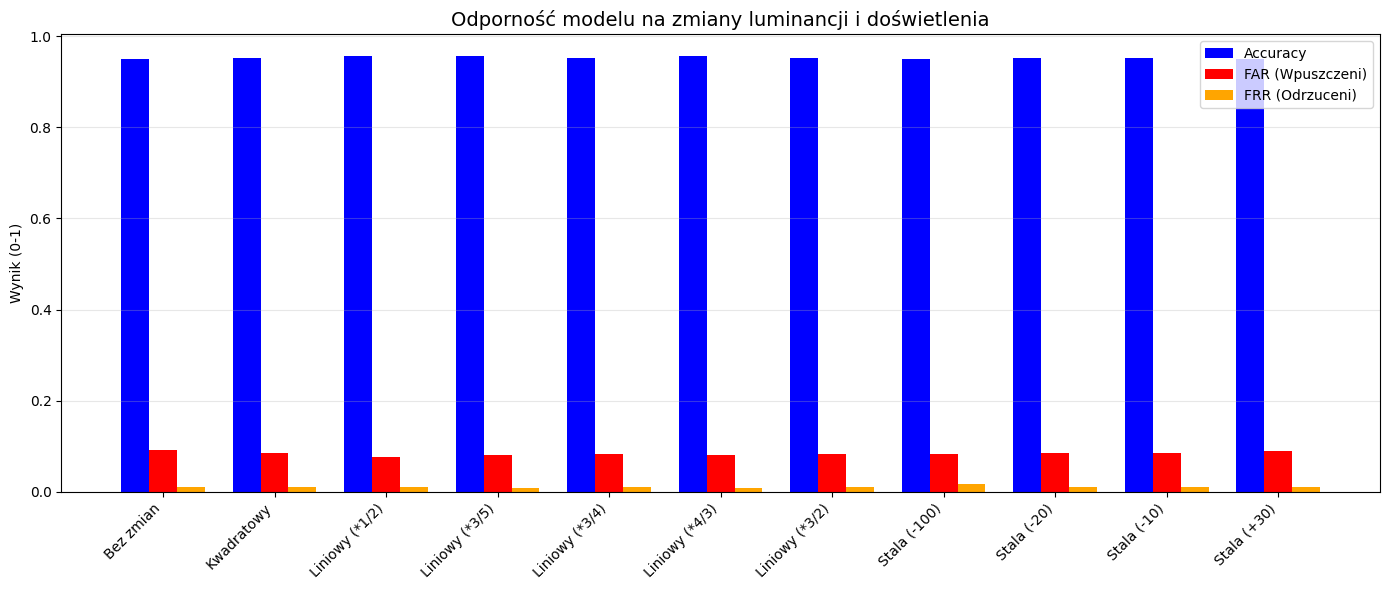


Podsumowanie liczbowe zmian luminancji:
Bez zmian          | Accuracy: 0.9494 | FAR: 0.0912 | FRR: 0.0100
Kwadratowy         | Accuracy: 0.9525 | FAR: 0.0850 | FRR: 0.0100
Liniowy (*1/2)     | Accuracy: 0.9563 | FAR: 0.0762 | FRR: 0.0112
Liniowy (*3/5)     | Accuracy: 0.9563 | FAR: 0.0800 | FRR: 0.0075
Liniowy (*3/4)     | Accuracy: 0.9531 | FAR: 0.0838 | FRR: 0.0100
Liniowy (*4/3)     | Accuracy: 0.9556 | FAR: 0.0800 | FRR: 0.0088
Liniowy (*3/2)     | Accuracy: 0.9525 | FAR: 0.0838 | FRR: 0.0112
Stala (-100)       | Accuracy: 0.9494 | FAR: 0.0838 | FRR: 0.0175
Stala (-20)        | Accuracy: 0.9525 | FAR: 0.0850 | FRR: 0.0100
Stala (-10)        | Accuracy: 0.9519 | FAR: 0.0862 | FRR: 0.0100
Stala (+30)        | Accuracy: 0.9500 | FAR: 0.0900 | FRR: 0.0100


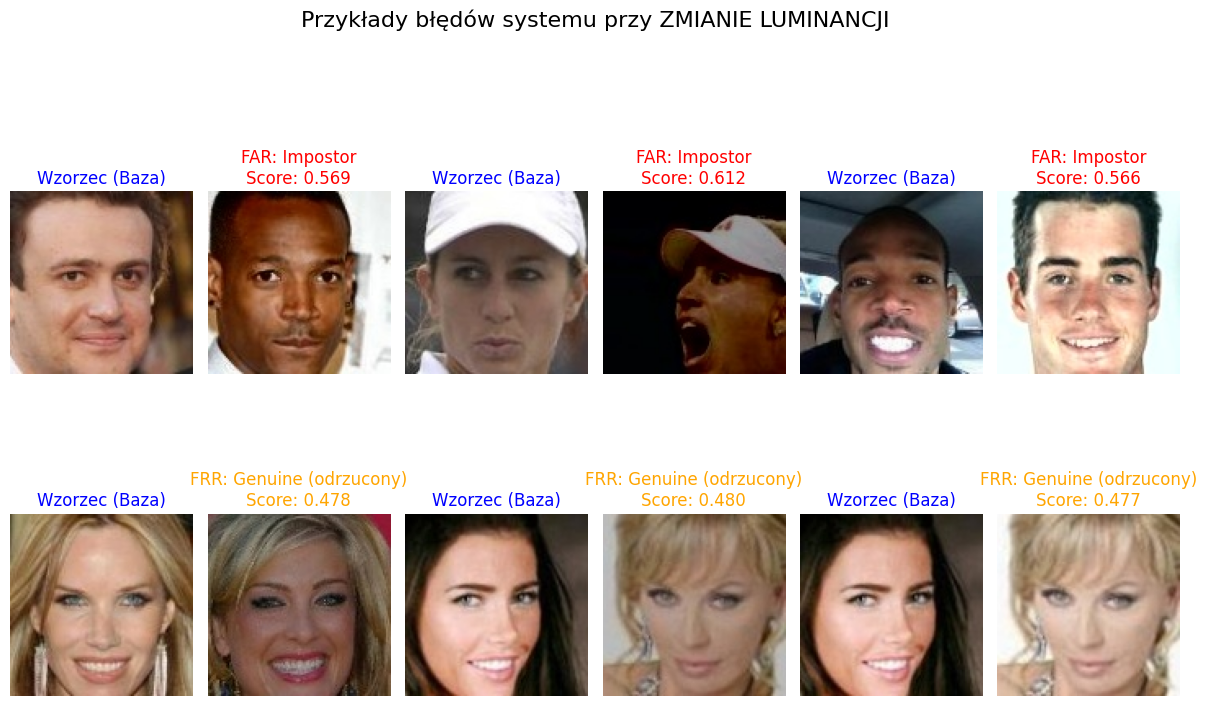

In [19]:
import cv2
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


os.makedirs("temp_lum", exist_ok=True)

def apply_luminance_transform(image_path, out_path, transform_type, value=None):
    img = cv2.imread(str(image_path))
    if img is None: return image_path
    
    yuv = cv2.cvtColor(img, cv2.COLOR_BGR2YUV)
    y, u, v = cv2.split(yuv)
    y = y.astype(np.float32)
    
    if transform_type == 'quadratic':
        y = 255.0 * ((y / 255.0) ** 2)
    elif transform_type == 'linear':
        y = y * value
    elif transform_type == 'constant':
        y = y + value
        
    y = np.clip(y, 0, 255).astype(np.uint8)
    yuv_new = cv2.merge([y, u, v])
    out_img = cv2.cvtColor(yuv_new, cv2.COLOR_YUV2BGR)
    
    cv2.imwrite(str(out_path), out_img)
    return out_path

def visualize_lum_errors(errors_dict, max_samples=3):
    """Wyświetla przykłady FAR i FRR dla zdjęć ze zmienioną luminancją."""
    has_fp = len(errors_dict['fp']) > 0
    has_fn = len(errors_dict['fn']) > 0
    
    if not has_fp and not has_fn:
        print("Brak pomyłek do wyświetlenia dla modyfikacji luminancji.")
        return

    fig, axes = plt.subplots(2, max_samples * 2, figsize=(4 * max_samples, 8))
    fig.suptitle("Przykłady błędów systemu przy ZMIANIE LUMINANCJI", fontsize=16, y=1.02)
    
    for i in range(max_samples):
        ax_base, ax_probe = axes[0, 2*i], axes[0, 2*i+1]
        if i < len(errors_dict['fp']):
            enroll_paths, probe_path, score = errors_dict['fp'][i]
            ax_base.imshow(Image.open(enroll_paths[0]))
            ax_base.set_title("Wzorzec (Baza)", color='blue')
            ax_probe.imshow(Image.open(probe_path))
            ax_probe.set_title(f"FAR: Impostor\nScore: {score:.3f}", color='red')
        ax_base.axis('off'); ax_probe.axis('off')

    for i in range(max_samples):
        ax_base, ax_probe = axes[1, 2*i], axes[1, 2*i+1]
        if i < len(errors_dict['fn']):
            enroll_paths, probe_path, score = errors_dict['fn'][i]
            ax_base.imshow(Image.open(enroll_paths[0]))
            ax_base.set_title("Wzorzec (Baza)", color='blue')
            ax_probe.imshow(Image.open(probe_path))
            ax_probe.set_title(f"FRR: Genuine (odrzucony)\nScore: {score:.3f}", color='orange')
        ax_base.axis('off'); ax_probe.axis('off')

    plt.tight_layout()
    plt.show()

lum_configs = [
    {"name": "Kwadratowy", "type": "quadratic", "val": None},
    {"name": "Liniowy (*1/2)", "type": "linear", "val": 0.5},
    {"name": "Liniowy (*3/5)", "type": "linear", "val": 0.6},
    {"name": "Liniowy (*3/4)", "type": "linear", "val": 0.75},
    {"name": "Liniowy (*4/3)", "type": "linear", "val": 1.33},
    {"name": "Liniowy (*3/2)", "type": "linear", "val": 1.5},
    {"name": "Stala (-100)", "type": "constant", "val": -100},
    {"name": "Stala (-20)", "type": "constant", "val": -20},
    {"name": "Stala (-10)", "type": "constant", "val": -10},
    {"name": "Stala (+30)", "type": "constant", "val": 30},
]

lum_test_cases = experiment_1_cases

results_lum = []
all_lum_errors = {'fp': [], 'fn': []}

print(f"=== EKSPERYMENT 4: Test Luminancji na {len(lum_test_cases)} zdjęciach ===")

print("Obliczanie statystyk dla zdjęć bazowych (Bez zmian)...")
acc_base, far_base, frr_base, errors_base = quick_eval_with_errors(lum_test_cases, threshold=THRESHOLD)
results_lum.append({'name': 'Bez zmian', 'acc': acc_base, 'far': far_base, 'frr': frr_base})
all_lum_errors['fp'].extend(errors_base['fp'])
all_lum_errors['fn'].extend(errors_base['fn'])

for conf in lum_configs:
    print(f"Przetwarzanie transformacji: {conf['name']}...")
    current_tests = []
    
    for i, (enroll_paths, profile_emb, probe_path, label) in enumerate(lum_test_cases):
        safe_val_str = str(conf['val']).replace(".", "_").replace("-", "m")
        temp_out = f"temp_lum/lum_{conf['type']}_{safe_val_str}_{i}.jpg"
        
        noisy_probe = apply_luminance_transform(probe_path, temp_out, conf['type'], conf['val'])
        current_tests.append((enroll_paths, profile_emb, noisy_probe, label))
        
    acc, far, frr, errors = quick_eval_with_errors(current_tests, threshold=THRESHOLD)
    results_lum.append({'name': conf['name'], 'acc': acc, 'far': far, 'frr': frr})
    
    all_lum_errors['fp'].extend(errors['fp'])
    all_lum_errors['fn'].extend(errors['fn'])

names = [res['name'] for res in results_lum]
acc_vals = [res['acc'] for res in results_lum]
far_vals = [res['far'] for res in results_lum]
frr_vals = [res['frr'] for res in results_lum]

x = np.arange(len(names))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
rects1 = ax.bar(x - width, acc_vals, width, label='Accuracy', color='blue')
rects2 = ax.bar(x, far_vals, width, label='FAR (Wpuszczeni)', color='red')
rects3 = ax.bar(x + width, frr_vals, width, label='FRR (Odrzuceni)', color='orange')

ax.set_ylabel('Wynik (0-1)')
ax.set_title('Odporność modelu na zmiany luminancji i doświetlenia', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=45, ha="right")
ax.legend()

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nPodsumowanie liczbowe zmian luminancji:")
for res in results_lum:
    print(f"{res['name']:<18} | Accuracy: {res['acc']:.4f} | FAR: {res['far']:.4f} | FRR: {res['frr']:.4f}")

random.shuffle(all_lum_errors['fp'])
random.shuffle(all_lum_errors['fn'])

visualize_lum_errors(all_lum_errors, max_samples=3)